# MAD-X model layer tests

This notebook tests the cleaned `MadxModel` workflow using several explicitly named machine states:

- `_default`: reference/perfect lattice, no error table, zero correctors
- `_misaligned`: same state with a MAD-X error table applied
- `_ops_correctors`: same misaligned state with non-zero corrector kicks
- `_tune_low` / `_tune_high`: Di Wright tune request checks
- `_madx_match`: MAD-X `match`-based tune request check
- `_harmonic`: harmonic trim setting check


In [1]:
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cycle_time import RCSRamp
from machine_state import MachineState
from machine_state_writer import write_machine_state_file
from madx_model import MadxModel


In [2]:
def get_madx_aperture_df(
    model,
    file_out=None,
    dqf=3.24,
    betaqfx=18.6669,
    interval=0.1,
):
    """
    Run MAD-X APERTURE using the existing active sequence in MadxModel.

    The aperture table is read back from the written TFS file rather than from
    model.madx.table.aperture.dframe(), because cpymad can fail to decode some
    aperture-table row names.
    """

    import os
    import pandas as pd

    if file_out is None:
        file_out = os.path.join(
            model.output_dir,
            f"{model.sequence_name}_madx_aperture.tfs",
        )

    output_dir = os.path.dirname(file_out)
    if output_dir != "":
        os.makedirs(output_dir, exist_ok=True)

    model.madx.input("select, flag=aperture, clear;")

    model.madx.input(
        "select, flag=aperture, "
        "column=name, n1, n1x_m, n1y_m, apertype, "
        "aper_1, aper_2, aper_3, aper_4, "
        "rtol, xtol, ytol, s, betx, bety, dx, dy, "
        "x, y, px, py, on_ap, on_elem, spec, x_pos_hit, y_pos_hit;"
    )

    model.madx.input('set, format="12.12f";')

    model.madx.input(
        f'aperture, range=#s/#e, dqf={dqf}, betaqfx={betaqfx}, '
        f'interval={interval}, file="{file_out}";'
    )

    try:
        import tfs

        aperture_df = tfs.read(file_out)

    except Exception:
        with open(file_out, "r", errors="replace") as f:
            lines = f.readlines()

        header_line = None
        type_line = None
        data_lines = []

        for line in lines:
            stripped = line.strip()

            if stripped.startswith("*"):
                header_line = stripped
            elif stripped.startswith("$"):
                type_line = stripped
            elif stripped and not stripped.startswith("@"):
                if not stripped.startswith("*") and not stripped.startswith("$"):
                    data_lines.append(stripped)

        if header_line is None:
            raise RuntimeError(f"Could not find TFS header line in {file_out}")

        columns = header_line.split()[1:]

        rows = []
        for line in data_lines:
            parts = line.split()

            if len(parts) == len(columns):
                rows.append(parts)

        aperture_df = pd.DataFrame(rows, columns=columns)

        for col in aperture_df.columns:
            if col.lower() not in ("name", "apertype"):
                aperture_df[col] = pd.to_numeric(aperture_df[col], errors="coerce")

    aperture_df.columns = [str(col).lower() for col in aperture_df.columns]

    model.aperture_df = aperture_df
    model.metadata["aperture_file_out"] = file_out
    model.metadata["aperture_rows"] = len(aperture_df)

    return aperture_df

In [3]:
# ------------------------------------------------------------------
# Global test configuration
# ------------------------------------------------------------------

LATTICE_FOLDER = "../Lattice_Files/00_Simplified_Lattice/"
APERTURE_LATTICE_FOLDER = "../Lattice_Files/03_CO_Kick_Lattice/"
APERTURE_FILE = "ISIS.aperture"
SEQUENCE_NAME = "synchrotron"

OUTPUT_DIR = "./madx_runs"
MACHINE_STATE_OUTPUT_DIR = "./machine_states"

ERROR_TABLE_PATH = "../Error_Tables/jan26_survey_corrected_hmatch.tfs"

TOP_ENERGY_MEV = 800.0
CYCLE_TIME_MS = 3.0

DEFAULT_QX = 4.295 #4.31 # 0ms setting 14.05.26 @ 17:00
DEFAULT_QY = 3.825 #3.76 # 0ms setting 14.05.26 @ 17:00

DEFAULT_MAIN_MAGNET_MODE = "srm_bare"
DEFAULT_TUNE_METHOD = "di_wright"

ramp = RCSRamp(top_energy_MeV=TOP_ENERGY_MEV)
beam_state = ramp.state_at(CYCLE_TIME_MS)

beam_state

RCSState(cycle_time_ms=3.0, kinetic_energy_MeV=172.56519175739015, total_energy_MeV=1110.83727991739, gamma=1.1839180701791945, beta=0.5353141487606986, momentum_MeV_c=594.6469129106272, brho_Tm=1.983528594674077, normalised_momentum=1.6109349966163502)

In [4]:
def make_state(
    suffix,
    requested_qx=DEFAULT_QX,
    requested_qy=DEFAULT_QY,
    main_magnet_mode="srm_bare",
    tune_method=DEFAULT_TUNE_METHOD,
    harmonic_tunes=None,
    error_table_path=None,
    hd_corrector_kicks_rad=None,
    vd_corrector_kicks_rad=None,
    hd_corrector_currents_A=None,
    vd_corrector_currents_A=None,
    corrector_prefer="kicks",
):
    machine_state = MachineState.from_defaults(
        beam_state=beam_state,
        main_magnet_mode=main_magnet_mode,
        requested_qx=requested_qx,
        requested_qy=requested_qy,
        tune_method=tune_method,
        harmonic_tunes=harmonic_tunes,
        error_table_path=error_table_path,
        hd_corrector_kicks_rad=hd_corrector_kicks_rad,
        vd_corrector_kicks_rad=vd_corrector_kicks_rad,
        hd_corrector_currents_A=hd_corrector_currents_A,
        vd_corrector_currents_A=vd_corrector_currents_A,
        corrector_prefer=corrector_prefer,
        metadata={"suffix": suffix},
    )

    state_file = write_machine_state_file(
        machine_state,
        output_dir=MACHINE_STATE_OUTPUT_DIR,
        filename=f"machine_state{suffix}.strength",
    )

    return machine_state, state_file

In [5]:
def run_model(
    suffix,
    machine_state_file,
    error_table_path=None,
    lattice_folder=LATTICE_FOLDER,
    sequence_name=SEQUENCE_NAME,
    output_dir=OUTPUT_DIR,
):
    model = MadxModel(
        lattice_folder=lattice_folder,
        sequence_name=sequence_name,
        machine_state_file=machine_state_file,
        aperture_file=APERTURE_FILE,
        output_dir=f"{output_dir}/{suffix.strip('_')}",
    )

    model.load_lattice(use_sequence=True)

    if error_table_path is not None:
        model.apply_error_table(error_table_path)

    twiss_df = model.run_twiss()
    summary_df = model.get_summary_df()

    return model, twiss_df, summary_df

In [6]:
def print_summary(label, summary_df):
    q1 = summary_df["q1"].iloc[0]
    q2 = summary_df["q2"].iloc[0]
    dq1 = summary_df["dq1"].iloc[0]
    dq2 = summary_df["dq2"].iloc[0]

    print(f"{label}")
    print(f"  Qx  = {q1:.6f}")
    print(f"  Qy  = {q2:.6f}")
    print(f"  dQx = {dq1:.6f}")
    print(f"  dQy = {dq2:.6f}")

## Build and run baseline models


In [7]:
# ------------------------------------------------------------------
# Aperture-only model
# ------------------------------------------------------------------
# This uses the more granular aperture/CO-kick lattice only to extract
# the aperture table for plotting. No error table or corrector changes
# are applied.

APERTURE_LATTICE_FOLDER = "../Lattice_Files/03_CO_Kick_Lattice/"

machine_state_aperture, state_file_aperture = make_state(
    suffix="_aperture",
    requested_qx=DEFAULT_QX,
    requested_qy=DEFAULT_QY,
    error_table_path=None,
)

model_aperture, twiss_df_aperture, summary_df_aperture = run_model(
    suffix="_aperture",
    machine_state_file=state_file_aperture,
    error_table_path=None,
    lattice_folder=APERTURE_LATTICE_FOLDER,
)

print_summary("aperture", summary_df_aperture)

aperture_df = get_madx_aperture_df(
    model_aperture,
    file_out="./madx_runs/aperture/aperture_lattice_aperture.tfs",
)

aperture_df.head()

aperture
  Qx  = 4.293521
  Qy  = 3.823497
  dQx = -8.631564
  dQy = -9.222536


,name,n1,n1x_m,n1y_m,apertype,aper_1,aper_2,aper_3,aper_4,rtol,...,dy,x,y,px,py,on_ap,on_elem,spec,x_pos_hit,y_pos_hit
0,SYNCHROTRON$START,999999.000000,999999.000000,999999.000000,RECTANGLE,0.087959,0.057091,0.104862,0.104862,0.0,...,0.0,0.0,0.0,0.0,0.0,-999999.0,1.0,0.0,999999.000000,999999.000000
1,SP0_DATUM,0.015896,0.056042,0.042954,RECTANGLE,0.087959,0.057091,0.104862,0.104862,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.042303,0.057091
2,SP0_DIPFR8_0,0.016075,0.056676,0.043440,RECTANGLE,0.087676,0.057682,0.104949,0.104949,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.042742,0.057682
3,SP0_DIPFR8_0,0.015890,0.055771,0.043432,RECTANGLE,0.087676,0.057682,0.104949,0.104949,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.042142,0.057682
4,SP0_DIPFR8_1,0.016186,0.056810,0.044242,RECTANGLE,0.087203,0.058667,0.105101,0.105101,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.042863,0.058667


In [8]:
# ------------------------------------------------------------------
# Default/perfect model: no error table, zero correctors
# ------------------------------------------------------------------

machine_state_default, state_file_default = make_state(
    suffix="_default",
    requested_qx=DEFAULT_QX,
    requested_qy=DEFAULT_QY,
    error_table_path=None,
)

model_default, twiss_df_default, summary_df_default = run_model(
    suffix="_default",
    machine_state_file=state_file_default,
    error_table_path=None,
)

print_summary("default", summary_df_default)


default
  Qx  = 4.293521
  Qy  = 3.823497
  dQx = -8.631564
  dQy = -9.222536


In [9]:
# ------------------------------------------------------------------
# Misaligned model: same machine state, with MAD-X error table
# ------------------------------------------------------------------

machine_state_misaligned, state_file_misaligned = make_state(
    suffix="_misaligned",
    requested_qx=DEFAULT_QX,
    requested_qy=DEFAULT_QY,
    error_table_path=ERROR_TABLE_PATH,
)

model_misaligned, twiss_df_misaligned, summary_df_misaligned = run_model(
    suffix="_misaligned",
    machine_state_file=state_file_misaligned,
    error_table_path=ERROR_TABLE_PATH,
)

print_summary("misaligned", summary_df_misaligned)


misaligned
  Qx  = 4.294115
  Qy  = 3.823485
  dQx = -8.636575
  dQy = -9.218671


In [10]:
# ------------------------------------------------------------------
# Misaligned model with corrector currents
# ------------------------------------------------------------------
# Corrector inputs are controls-style currents in amperes.
# Values taken from operation 14.05.26 @ 17:00 (0 ms values)

hd_corrector_currents_A_random_correctors = OrderedDict(
    [
        ("r0hd1_kick", 5),
        ("r2hd1_kick", 1.2),
        ("r3hd1_kick", 1),
        ("r4hd1_kick", -2.8),
        ("r5hd1_kick", 7.6),
        ("r7hd1_kick", 12.0),
        ("r9hd1_kick", 6.3),
    ]
)

vd_corrector_currents_A_random_correctors = OrderedDict(
    [
        ("r0vd1_kick", -8.6),
        ("r2vd1_kick", 2.0),
        ("r3vd1_kick", 7.0),
        ("r4vd1_kick", -2.0),
        ("r5vd1_kick", -1.0),
        ("r7vd1_kick", -6.0),
        ("r9vd1_kick", 8.1),
    ]
)

machine_state_random_correctors, state_file_random_correctors = make_state(
    suffix="_ops_correctors",
    requested_qx=DEFAULT_QX,
    requested_qy=DEFAULT_QY,
    error_table_path=ERROR_TABLE_PATH,
    hd_corrector_currents_A=hd_corrector_currents_A_random_correctors,
    vd_corrector_currents_A=vd_corrector_currents_A_random_correctors,
    corrector_prefer="currents",
)

model_random_correctors, twiss_df_random_correctors, summary_df_random_correctors = run_model(
    suffix="_ops_correctors",
    machine_state_file=state_file_random_correctors,
    error_table_path=ERROR_TABLE_PATH,
)

print_summary("_ops_correctors", summary_df_random_correctors)

_ops_correctors
  Qx  = 4.294471
  Qy  = 3.823611
  dQx = -8.636339
  dQy = -9.218575


## Basic plots


In [11]:
def plot_twiss_functions(twiss_df, label=""):
    fig, ax = plt.subplots(figsize=(9, 5))

    ax.plot(
        twiss_df["s"],
        twiss_df["betx"],
        label=rf"$\beta_x$ {label}",
    )

    ax.plot(
        twiss_df["s"],
        twiss_df["bety"],
        label=rf"$\beta_y$ {label}",
    )

    ax.set_xlabel("s [m]")
    ax.set_ylabel(r"$\beta$ [m]")
    ax.set_title(f"Twiss functions {label}")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.show()


def plot_dispersion(twiss_df, beam_state, label=""):
    fig, ax = plt.subplots(figsize=(9, 5))

    lorentz_beta = beam_state.beta

    ax.plot(
        twiss_df["s"],
        lorentz_beta * twiss_df["dx"],
        label=rf"$\beta D_x$ {label}",
    )

    ax.plot(
        twiss_df["s"],
        lorentz_beta * twiss_df["dy"],
        label=rf"$\beta D_y$ {label}",
    )

    ax.set_xlabel("s [m]")
    ax.set_ylabel(r"$\beta D$ [m]")
    ax.set_title(f"Dispersion {label}")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.show()


def plot_closed_orbit(twiss_df, label=""):
    fig, ax = plt.subplots(figsize=(9, 5))

    ax.plot(twiss_df["s"], 1e3 * twiss_df["x"], label="x")
    ax.plot(twiss_df["s"], 1e3 * twiss_df["y"], label="y")

    ax.set_xlabel("s [m]")
    ax.set_ylabel("Closed orbit [mm]")
    ax.set_title(f"ISIS RCS closed orbit {label}")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.show()


def plot_k1l(twiss_df, label=""):
    fig, ax = plt.subplots(figsize=(9, 5))

    ax.bar(
        twiss_df["s"],
        twiss_df["k1l"],
        width=0.25,
        align="center",
    )

    ax.set_xlabel("s [m]")
    ax.set_ylabel(r"$K_1L$ [m$^{-1}$]")
    ax.set_title(f"Integrated quadrupole strength {label}")
    ax.grid(True, alpha=0.3)

    plt.show()


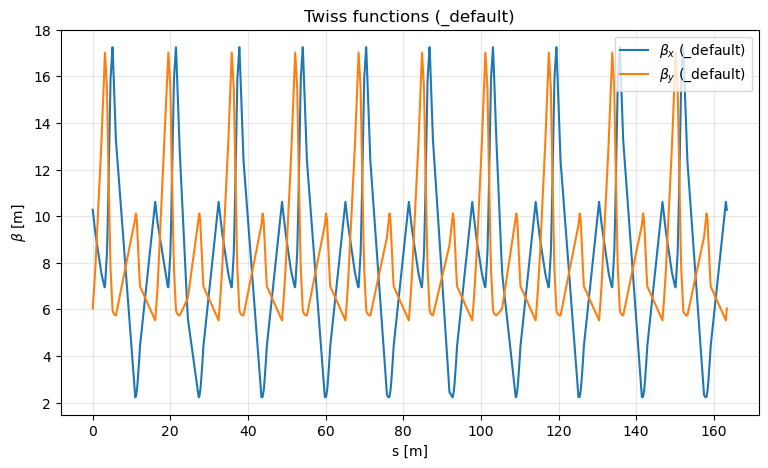

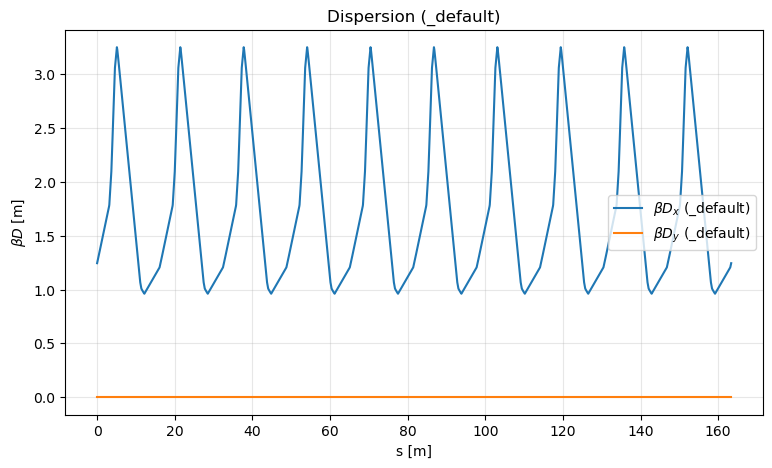

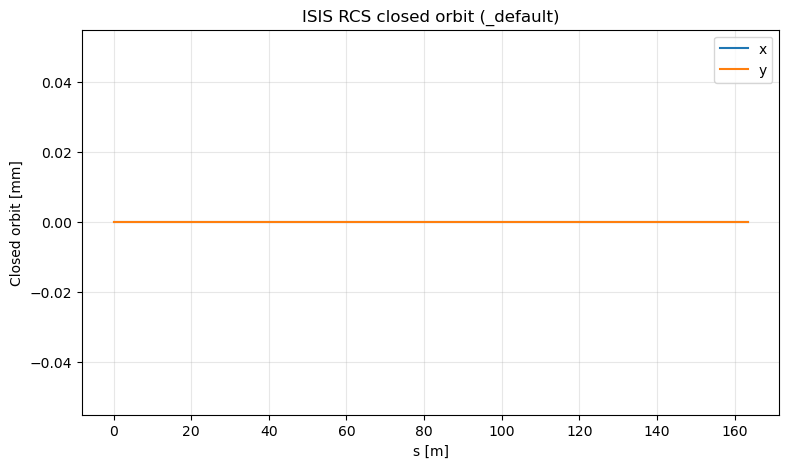

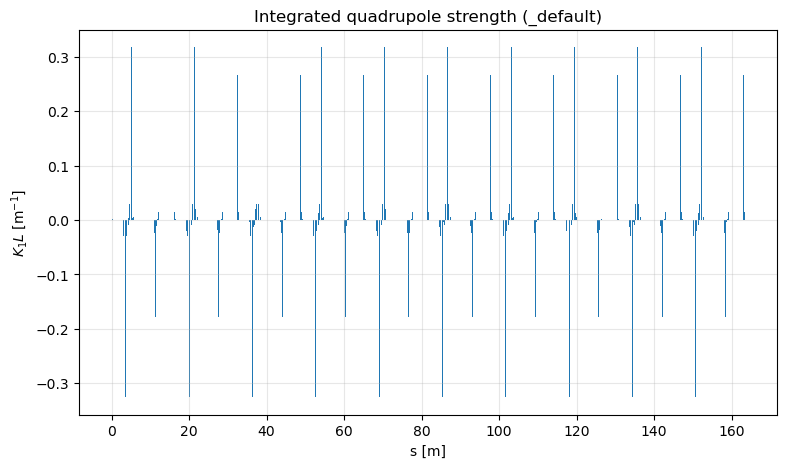

In [12]:
plot_twiss_functions(twiss_df_default, label="(_default)")
plot_dispersion(twiss_df_default, beam_state, label="(_default)")
plot_closed_orbit(twiss_df_default, label="(_default)")
plot_k1l(twiss_df_default, label="(_default)")


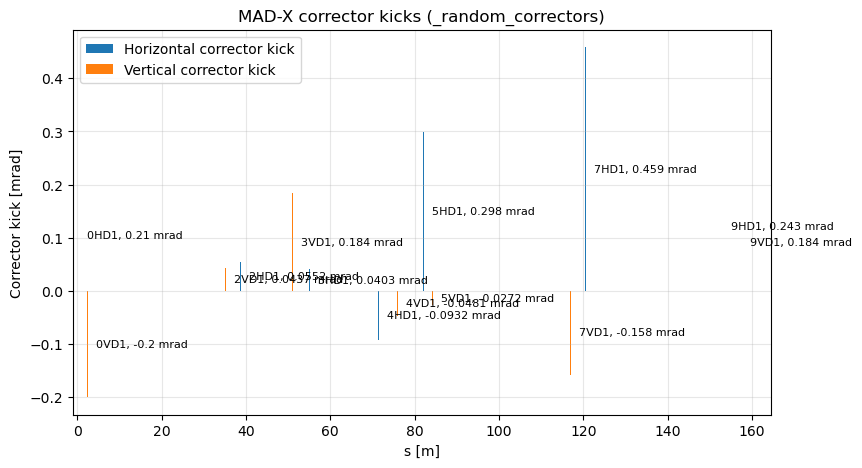

In [13]:
def format_corrector_name(name):
    name = str(name).lower()

    if "_" in name:
        name = name.split("_")[-1]

    if ":" in name:
        name = name.split(":")[0]

    name = name.replace("r", "", 1)

    return name.upper()


def plot_corrector_kicks(twiss_df, label=""):
    fig, ax = plt.subplots(figsize=(9, 5))

    bar_width = 0.20
    x_padding = 1.0

    x_h = twiss_df["s"] - 0.5 * bar_width
    x_v = twiss_df["s"] + 0.5 * bar_width

    h_kick_mrad = 1e3 * twiss_df["hkick"]
    v_kick_mrad = 1e3 * twiss_df["vkick"]

    ax.bar(
        x_h,
        h_kick_mrad,
        width=bar_width,
        align="center",
        label="Horizontal corrector kick",
    )

    ax.bar(
        x_v,
        v_kick_mrad,
        width=bar_width,
        align="center",
        label="Vertical corrector kick",
    )

    non_zero_threshold = 1.0e-12

    for _, row in twiss_df.iterrows():
        s = row["s"]
        name = format_corrector_name(row["name"])

        hkick = 1e3 * row["hkick"]
        vkick = 1e3 * row["vkick"]

        if abs(hkick) > non_zero_threshold:
            ax.annotate(
                f"{name}, {hkick:.3g} mrad",
                xy=(s - 0.5 * bar_width, 0.5 * hkick),
                xytext=(6, 0),
                textcoords="offset points",
                ha="left",
                va="center",
                fontsize=8,
            )

        if abs(vkick) > non_zero_threshold:
            ax.annotate(
                f"{name}, {vkick:.3g} mrad",
                xy=(s + 0.5 * bar_width, 0.5 * vkick),
                xytext=(6, 0),
                textcoords="offset points",
                ha="left",
                va="center",
                fontsize=8,
            )

    ax.set_xlim(
        twiss_df["s"].min() - x_padding,
        twiss_df["s"].max() + x_padding,
    )

    ax.set_xlabel("s [m]")
    ax.set_ylabel("Corrector kick [mrad]")
    ax.set_title(f"MAD-X corrector kicks {label}")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.show()


plot_corrector_kicks(twiss_df_random_correctors, label="(_random_correctors)")


## Orbit comparison: perfect vs misaligned vs random correctors


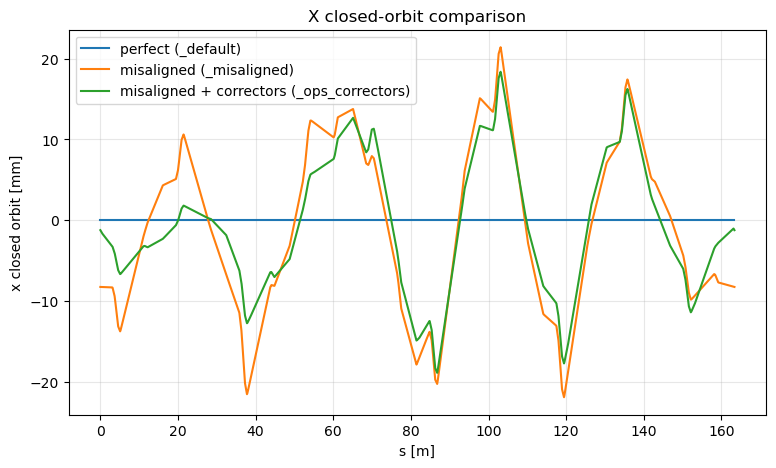

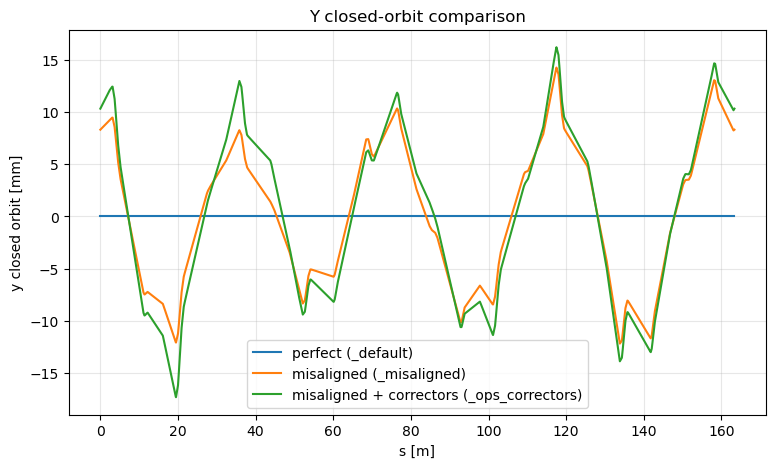

In [14]:
def plot_orbit_comparison(twiss_dict, plane="x"):
    fig, ax = plt.subplots(figsize=(9, 5))

    for label, df in twiss_dict.items():
        ax.plot(df["s"], 1e3 * df[plane], label=label)

    ax.set_xlabel("s [m]")
    ax.set_ylabel(f"{plane} closed orbit [mm]")
    ax.set_title(f"{plane.upper()} closed-orbit comparison")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.show()


twiss_orbit_models = {
    "perfect (_default)": twiss_df_default,
    "misaligned (_misaligned)": twiss_df_misaligned,
    "misaligned + correctors (_ops_correctors)": twiss_df_random_correctors,
}

plot_orbit_comparison(twiss_orbit_models, plane="x")
plot_orbit_comparison(twiss_orbit_models, plane="y")


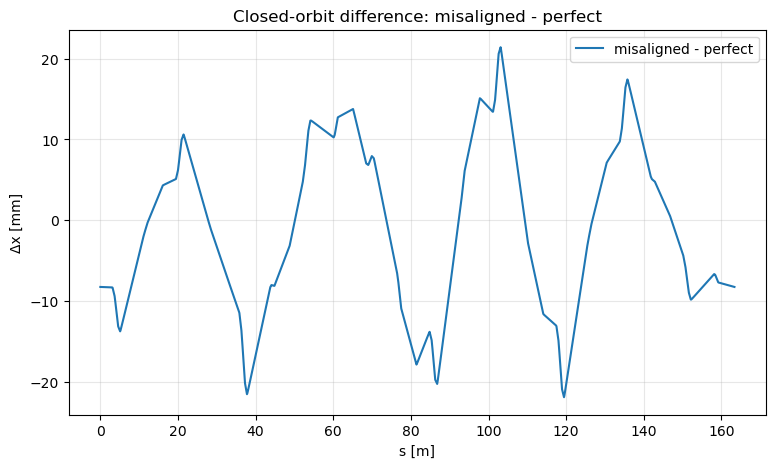

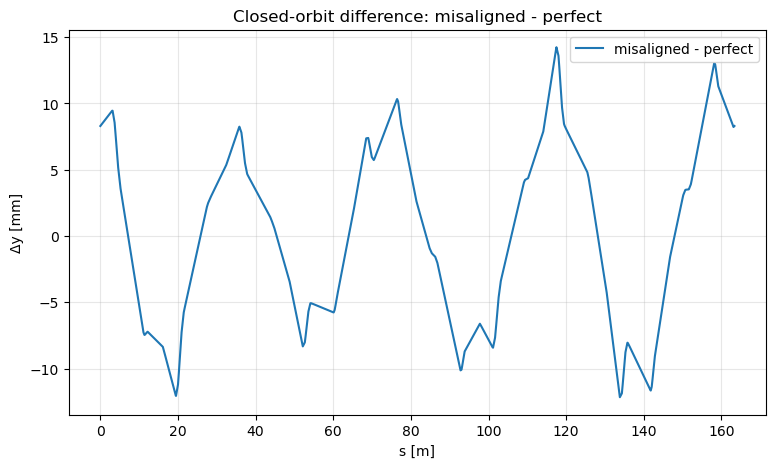

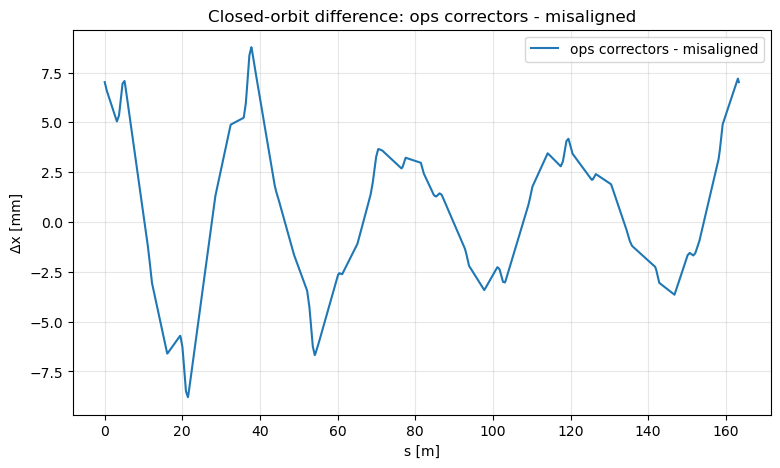

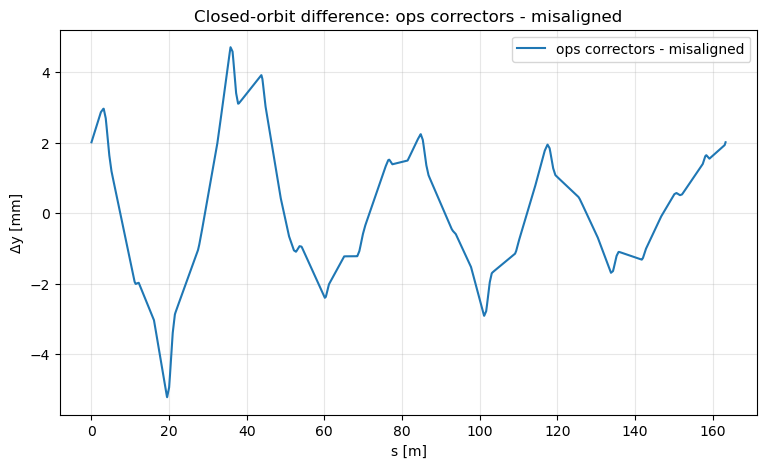

In [15]:
def plot_orbit_difference(df_ref, df_other, label, plane="x"):
    fig, ax = plt.subplots(figsize=(9, 5))

    ax.plot(
        df_ref["s"],
        1e3 * (df_other[plane].values - df_ref[plane].values),
        label=label,
    )

    ax.set_xlabel("s [m]")
    ax.set_ylabel(f"Δ{plane} [mm]")
    ax.set_title(f"Closed-orbit difference: {label}")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.show()


plot_orbit_difference(
    twiss_df_default,
    twiss_df_misaligned,
    label="misaligned - perfect",
    plane="x",
)

plot_orbit_difference(
    twiss_df_default,
    twiss_df_misaligned,
    label="misaligned - perfect",
    plane="y",
)

plot_orbit_difference(
    twiss_df_misaligned,
    twiss_df_random_correctors,
    label="ops correctors - misaligned",
    plane="x",
)

plot_orbit_difference(
    twiss_df_misaligned,
    twiss_df_random_correctors,
    label="ops correctors - misaligned",
    plane="y",
)


## Tune request comparison


In [16]:
# ------------------------------------------------------------------
# Tune request models
# ------------------------------------------------------------------

machine_state_tune_low, state_file_tune_low = make_state(
    suffix="_tune_low",
    requested_qx=4.26,
    requested_qy=3.72,
    error_table_path=None,
)

model_tune_low, twiss_df_tune_low, summary_df_tune_low = run_model(
    suffix="_tune_low",
    machine_state_file=state_file_tune_low,
    error_table_path=None,
)

machine_state_tune_high, state_file_tune_high = make_state(
    suffix="_tune_high",
    requested_qx=4.36,
    requested_qy=3.80,
    error_table_path=None,
)

model_tune_high, twiss_df_tune_high, summary_df_tune_high = run_model(
    suffix="_tune_high",
    machine_state_file=state_file_tune_high,
    error_table_path=None,
)

print_summary("tune_low", summary_df_tune_low)
print_summary("default", summary_df_default)
print_summary("tune_high", summary_df_tune_high)


tune_low
  Qx  = 4.273105
  Qy  = 3.758117
  dQx = -8.353060
  dQy = -8.845661
default
  Qx  = 4.293521
  Qy  = 3.823497
  dQx = -8.631564
  dQy = -9.222536
tune_high
  Qx  = 4.335189
  Qy  = 3.808815
  dQx = -9.136281
  dQy = -9.239832


In [17]:
def summary_row(label, requested_qx, requested_qy, summary_df, machine_state):
    return {
        "label": label,
        "requested_qx": requested_qx,
        "requested_qy": requested_qy,
        "madx_qx": summary_df["q1"].iloc[0],
        "madx_qy": summary_df["q2"].iloc[0],
        "kqtf": machine_state.kqtf,
        "kqtd": machine_state.kqtd,
        "iqtf_A": machine_state.iqtf_A,
        "iqtd_A": machine_state.iqtd_A,
    }


tune_summary_df = pd.DataFrame(
    [
        summary_row("_tune_low", 4.26, 3.72, summary_df_tune_low, machine_state_tune_low),
        summary_row("_default", DEFAULT_QX, DEFAULT_QY, summary_df_default, machine_state_default),
        summary_row("_tune_high", 4.36, 3.80, summary_df_tune_high, machine_state_tune_high),
    ]
)

tune_summary_df


,label,requested_qx,requested_qy,madx_qx,madx_qy,kqtf,kqtd,iqtf_A,iqtd_A
0,_tune_low,4.260,3.720,4.273105,3.758117,-0.024209,0.015545,-38.735705,24.873253
1,_default,4.295,3.825,4.293521,3.823497,0.018712,-0.031359,29.939696,-50.175991
2,_tune_high,4.360,3.800,4.335189,3.808815,0.029961,-0.031770,47.940145,-50.833902


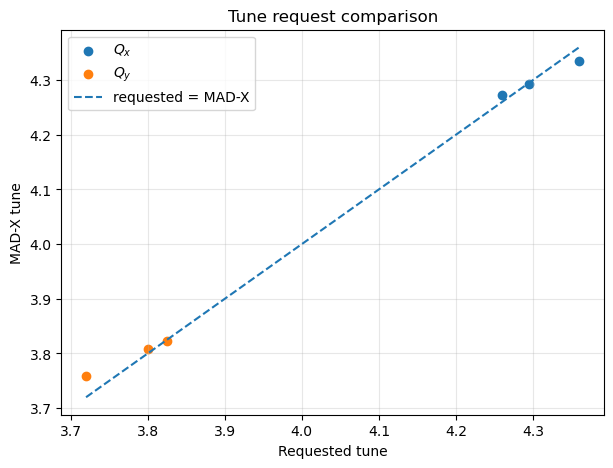

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    tune_summary_df["requested_qx"],
    tune_summary_df["madx_qx"],
    label=r"$Q_x$",
)

ax.scatter(
    tune_summary_df["requested_qy"],
    tune_summary_df["madx_qy"],
    label=r"$Q_y$",
)

q_min = min(
    tune_summary_df["requested_qx"].min(),
    tune_summary_df["requested_qy"].min(),
    tune_summary_df["madx_qx"].min(),
    tune_summary_df["madx_qy"].min(),
)
q_max = max(
    tune_summary_df["requested_qx"].max(),
    tune_summary_df["requested_qy"].max(),
    tune_summary_df["madx_qx"].max(),
    tune_summary_df["madx_qy"].max(),
)

ax.plot([q_min, q_max], [q_min, q_max], "--", label="requested = MAD-X")

ax.set_xlabel("Requested tune")
ax.set_ylabel("MAD-X tune")
ax.set_title("Tune request comparison")
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()


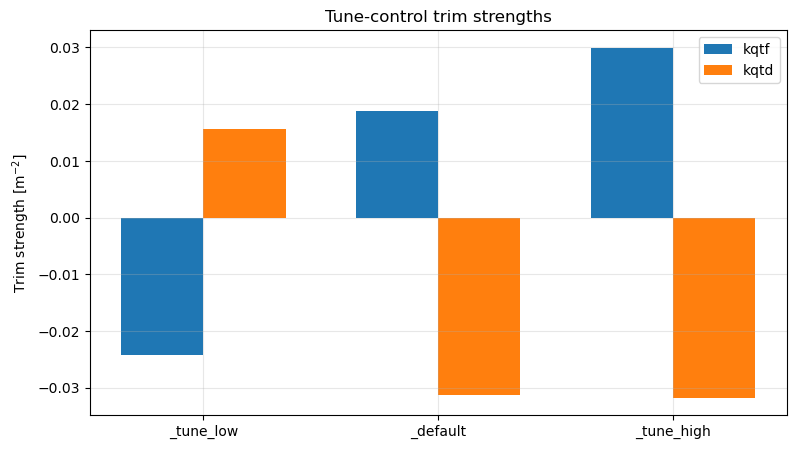

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(tune_summary_df))
bar_width = 0.35

ax.bar(
    x - 0.5 * bar_width,
    tune_summary_df["kqtf"],
    width=bar_width,
    label="kqtf",
)

ax.bar(
    x + 0.5 * bar_width,
    tune_summary_df["kqtd"],
    width=bar_width,
    label="kqtd",
)

ax.set_xticks(x)
ax.set_xticklabels(tune_summary_df["label"])
ax.set_ylabel(r"Trim strength [m$^{-2}$]")
ax.set_title("Tune-control trim strengths")
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()


## MAD-X match tune test

This checks the `MadxModel.match_tune_from_machine_state(...)` path. The `MachineState` stores the requested tunes, while `MadxModel` owns the cpymad/MAD-X match and writes the matched trim strengths back into the state.


In [20]:
# ------------------------------------------------------------------
# MAD-X match tune model
# ------------------------------------------------------------------
# MachineState stores the request. MadxModel performs the MAD-X match.
# For this workflow, do not call USE during load_lattice().
# The beam is applied by match_tune_from_machine_state(...) before USE.

machine_state_madx_match = MachineState.from_defaults(
    beam_state=beam_state,
    main_magnet_mode=DEFAULT_MAIN_MAGNET_MODE,
    requested_qx=DEFAULT_QX,
    requested_qy=DEFAULT_QY,
    tune_method="madx_match",
    calculate_tune=False,
    metadata={"suffix": "_madx_match"},
)

model_madx_match = MadxModel(
    lattice_folder=LATTICE_FOLDER,
    sequence_name=SEQUENCE_NAME,
    aperture_file=APERTURE_FILE,
    output_dir=f"{OUTPUT_DIR}/madx_match",
)

model_madx_match.load_lattice(use_sequence=False)

match_result = model_madx_match.match_tune_from_machine_state(
    machine_state_madx_match,
    include_trim_quads=False,
)

twiss_df_madx_match = model_madx_match.run_twiss()
summary_df_madx_match = model_madx_match.get_summary_df()

assert model_madx_match.metadata["machine_state_applied"] is True
assert "madx_match" in machine_state_madx_match.metadata
assert np.isfinite(machine_state_madx_match.kqtf)
assert np.isfinite(machine_state_madx_match.kqtd)
assert np.isfinite(machine_state_madx_match.iqtf_A)
assert np.isfinite(machine_state_madx_match.iqtd_A)

assert abs(summary_df_madx_match["q1"].iloc[0] - DEFAULT_QX) < 1.0e-3
assert abs(summary_df_madx_match["q2"].iloc[0] - DEFAULT_QY) < 1.0e-3

print_summary("madx_match", summary_df_madx_match)
match_result

madx_match
  Qx  = 4.295004
  Qy  = 3.825004
  dQx = -8.650044
  dQy = -9.234116


{'kqtd': -0.0326017060138176,
 'kqtf': 0.020080616152055798,
 'iqtd_A': -52.164943827289626,
 'iqtf_A': 32.13034965548708,
 'matched_qx': np.float64(4.295004230370187),
 'matched_qy': np.float64(3.825004052887421),
 'matched_dqx': np.float64(-8.65004362417021),
 'matched_dqy': np.float64(-9.234115529701427)}

In [21]:
# ------------------------------------------------------------------
# Write the matched state to file and reload it through the standard path
# ------------------------------------------------------------------

state_file_madx_match = write_machine_state_file(
    machine_state_madx_match,
    output_dir=MACHINE_STATE_OUTPUT_DIR,
    filename="machine_state_madx_match.strength",
)

model_madx_match_file, twiss_df_madx_match_file, summary_df_madx_match_file = run_model(
    suffix="_madx_match_file",
    machine_state_file=state_file_madx_match,
    error_table_path=None,
)

assert abs(summary_df_madx_match_file["q1"].iloc[0] - DEFAULT_QX) < 1.0e-3
assert abs(summary_df_madx_match_file["q2"].iloc[0] - DEFAULT_QY) < 1.0e-3

assert abs(summary_df_madx_match_file["q1"].iloc[0] - summary_df_madx_match["q1"].iloc[0]) < 1.0e-6
assert abs(summary_df_madx_match_file["q2"].iloc[0] - summary_df_madx_match["q2"].iloc[0]) < 1.0e-6

print_summary("madx_match_file", summary_df_madx_match_file)


madx_match_file
  Qx  = 4.295004
  Qy  = 3.825004
  dQx = -8.650044
  dQy = -9.234116


## Harmonic trim test


In [22]:
harmonic_tunes = OrderedDict(
    [
        ("D7SIN",  2.0),
        ("D7COS",  0.0),
        ("D8SIN",  0.0),
        ("D8COS",  0.0),
        ("F8SIN",  0.0),
        ("F8COS",  2.0),
        ("F9SIN",  0.0),
        ("F9COS",  0.0),
    ]
)

machine_state_harmonic, state_file_harmonic = make_state(
    suffix="_harmonic",
    requested_qx=DEFAULT_QX,
    requested_qy=DEFAULT_QY,
    error_table_path=ERROR_TABLE_PATH,
    harmonic_tunes=harmonic_tunes,
)

model_harmonic, twiss_df_harmonic, summary_df_harmonic = run_model(
    suffix="_harmonic",
    machine_state_file=state_file_harmonic,
    error_table_path=ERROR_TABLE_PATH,
)

print_summary("harmonic", summary_df_harmonic)


harmonic
  Qx  = 4.294079
  Qy  = 3.823478
  dQx = -8.637092
  dQy = -9.219572


In [23]:
def extract_superperiod(name):
    name = str(name).lower()

    if name.startswith("sp"):
        return int(name.split("_")[0].replace("sp", ""))

    if "_r" in name:
        return int(name.split("_r")[1][0])

    return np.nan


def harmonic_qtd(sp, harmonic_tunes, brho_Tm):
    theta = 2.0 * np.pi * sp / 10.0

    tqgcal = 1.997e-3
    hqcal = 1.25

    d7sin = harmonic_tunes.get("D7SIN", 0.0)
    d7cos = harmonic_tunes.get("D7COS", 0.0)
    d8sin = harmonic_tunes.get("D8SIN", 0.0)
    d8cos = harmonic_tunes.get("D8COS", 0.0)

    return (
        d7cos * hqcal * tqgcal / brho_Tm * np.cos(7.0 * theta)
        + d7sin * hqcal * tqgcal / brho_Tm * np.sin(7.0 * theta)
        + d8cos * hqcal * tqgcal / brho_Tm * np.cos(8.0 * theta)
        + d8sin * hqcal * tqgcal / brho_Tm * np.sin(8.0 * theta)
    )


def harmonic_qtf(sp, harmonic_tunes, brho_Tm):
    theta = 2.0 * np.pi * sp / 10.0

    tqgcal = 1.997e-3
    hqcal = 1.25

    f8sin = harmonic_tunes.get("F8SIN", 0.0)
    f8cos = harmonic_tunes.get("F8COS", 0.0)
    f9sin = harmonic_tunes.get("F9SIN", 0.0)
    f9cos = harmonic_tunes.get("F9COS", 0.0)

    return (
        f8cos * hqcal * tqgcal / brho_Tm * np.cos(8.0 * theta)
        + f8sin * hqcal * tqgcal / brho_Tm * np.sin(8.0 * theta)
        + f9cos * hqcal * tqgcal / brho_Tm * np.cos(9.0 * theta)
        + f9sin * hqcal * tqgcal / brho_Tm * np.sin(9.0 * theta)
    )


QTD length from TWISS = 0.307 m
QTF length from TWISS = 0.307 m


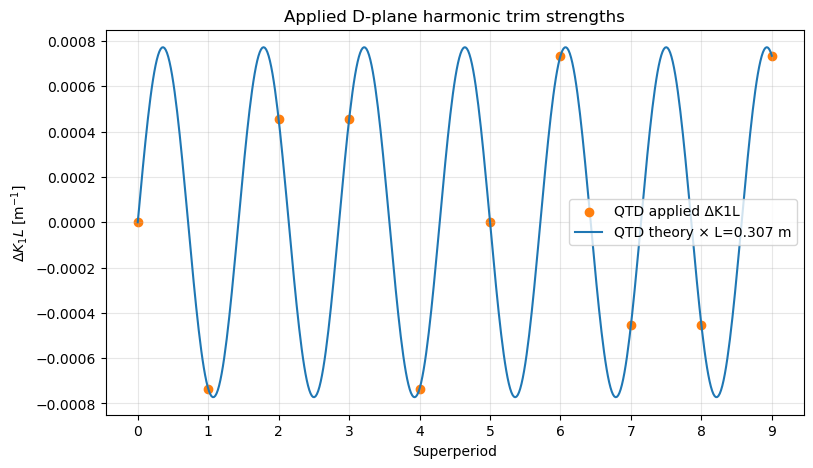

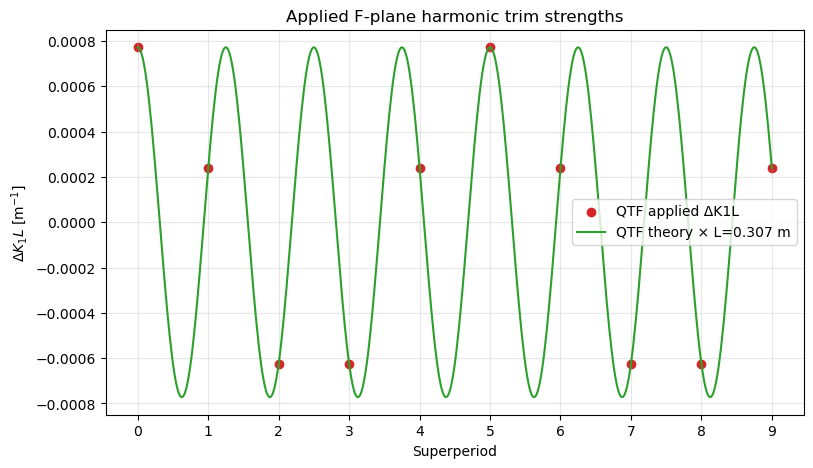

In [24]:
def plot_harmonic_trim_comparison(twiss_df, twiss_df_reference, harmonic_tunes, beam_state):
    df_compare = twiss_df.copy()
    df_compare["k1l_reference"] = twiss_df_reference["k1l"].values
    df_compare["delta_k1l"] = df_compare["k1l"] - df_compare["k1l_reference"]
    df_compare["sp"] = df_compare["name"].apply(extract_superperiod)

    df_trim = df_compare[
        df_compare["name"].str.lower().str.contains("qtf|qtd", regex=True)
    ].copy()

    df_trim = df_trim.dropna(subset=["sp"])

    df_qtd = df_trim[df_trim["name"].str.lower().str.contains("qtd")].copy()
    df_qtf = df_trim[df_trim["name"].str.lower().str.contains("qtf")].copy()

    df_qtd = df_qtd.sort_values("sp")
    df_qtf = df_qtf.sort_values("sp")

    qtd_length = np.nanmedian(df_qtd["l"].values)
    qtf_length = np.nanmedian(df_qtf["l"].values)

    print(f"QTD length from TWISS = {qtd_length:.6g} m")
    print(f"QTF length from TWISS = {qtf_length:.6g} m")

    sp_dense = np.linspace(0.0, 9.0, 500)

    qtd_theory_dense = qtd_length * harmonic_qtd(
        sp=sp_dense,
        harmonic_tunes=harmonic_tunes,
        brho_Tm=beam_state.brho_Tm,
    )

    qtf_theory_dense = qtf_length * harmonic_qtf(
        sp=sp_dense,
        harmonic_tunes=harmonic_tunes,
        brho_Tm=beam_state.brho_Tm,
    )

    qtd_theory_colour = "tab:blue"
    qtd_scatter_colour = "tab:orange"

    qtf_theory_colour = "tab:green"
    qtf_scatter_colour = "tab:red"

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.scatter(
        df_qtd["sp"],
        df_qtd["delta_k1l"],
        color=qtd_scatter_colour,
        label="QTD applied ΔK1L",
    )

    ax.plot(
        sp_dense,
        qtd_theory_dense,
        "-",
        color=qtd_theory_colour,
        label=f"QTD theory × L={qtd_length:.3g} m",
    )

    ax.set_xlabel("Superperiod")
    ax.set_ylabel(r"$\Delta K_1L$ [m$^{-1}$]")
    ax.set_title("Applied D-plane harmonic trim strengths")
    ax.set_xticks(range(10))
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.show()

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.scatter(
        df_qtf["sp"],
        df_qtf["delta_k1l"],
        color=qtf_scatter_colour,
        label="QTF applied ΔK1L",
    )

    ax.plot(
        sp_dense,
        qtf_theory_dense,
        "-",
        color=qtf_theory_colour,
        label=f"QTF theory × L={qtf_length:.3g} m",
    )

    ax.set_xlabel("Superperiod")
    ax.set_ylabel(r"$\Delta K_1L$ [m$^{-1}$]")
    ax.set_title("Applied F-plane harmonic trim strengths")
    ax.set_xticks(range(10))
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.show()


plot_harmonic_trim_comparison(
    twiss_df=twiss_df_harmonic,
    twiss_df_reference=twiss_df_misaligned,
    harmonic_tunes=harmonic_tunes,
    beam_state=beam_state,
)


In [25]:
def plot_aperture_orbit_envelope_xy(
    twiss_df,
    aperture_df=None,
    beam_state=None,
    emittance_x_mm_mrad=300.0,
    emittance_y_mm_mrad=300.0,
    emittance_is_normalised=True,
    emittance_scale_factor=1.0,
    n_sigma=3.0,
    delta_p=0.002,
    label="",
    savefig=None,
    xlims=None,
    ylims_x=None,
    ylims_y=None,
):
    """
    Plot horizontal and vertical closed orbit, betatron envelope,
    dispersive envelope, and optional aperture.

    Envelope convention
    -------------------
    Horizontal:
        betatron envelope = n_sigma * sqrt(beta_x * eps_x)
        dispersive envelope = betatron envelope + |D_x * delta_p|

    Vertical:
        betatron envelope = n_sigma * sqrt(beta_y * eps_y)
        dispersive envelope = betatron envelope + |D_y * delta_p|

    Aperture convention
    -------------------
    For MAD-X rectangular apertures, use aper_1 and aper_2 as the physical
    horizontal and vertical half-apertures.

    Emittance convention
    --------------------
    If emittance_is_normalised=True:
        eps_geometric = eps_normalised / (beta_rel * gamma_rel)

    If emittance_is_normalised=False:
        emittance is treated directly as geometric emittance.

    emittance_scale_factor can be used to convert from a quoted full/acceptance
    emittance into the effective RMS emittance used for the plotted envelope.

    Units
    -----
    twiss_df orbit/aperture values are assumed to be in metres.
    Emittance is supplied in mm mrad.
    """

    import numpy as np
    import matplotlib.pyplot as plt

    # ------------------------------------------------------------------
    # Emittance conversion
    # ------------------------------------------------------------------

    emittance_x_m_rad = emittance_x_mm_mrad * 1.0e-6
    emittance_y_m_rad = emittance_y_mm_mrad * 1.0e-6

    if emittance_is_normalised:
        if beam_state is None:
            raise ValueError(
                "beam_state must be supplied when emittance_is_normalised=True."
            )

        beta_gamma = float(beam_state.beta) * float(beam_state.gamma)

        if beta_gamma == 0.0:
            raise ZeroDivisionError("beam_state.beta * beam_state.gamma is zero.")

        emittance_x_m_rad = emittance_x_m_rad / beta_gamma
        emittance_y_m_rad = emittance_y_m_rad / beta_gamma

    emittance_x_m_rad = emittance_x_m_rad * float(emittance_scale_factor)
    emittance_y_m_rad = emittance_y_m_rad * float(emittance_scale_factor)

    # ------------------------------------------------------------------
    # Twiss data
    # ------------------------------------------------------------------

    s = twiss_df["s"].values

    x = twiss_df["x"].values
    y = twiss_df["y"].values

    betx = twiss_df["betx"].values
    bety = twiss_df["bety"].values

    dx = twiss_df["dx"].values
    dy = twiss_df["dy"].values

    x_beta_envelope = n_sigma * np.sqrt(betx * emittance_x_m_rad)
    y_beta_envelope = n_sigma * np.sqrt(bety * emittance_y_m_rad)

    x_dispersion = np.abs(dx * delta_p)
    y_dispersion = np.abs(dy * delta_p)

    x_total_envelope = x_beta_envelope + x_dispersion
    y_total_envelope = y_beta_envelope + y_dispersion

    fig, (ax_x, ax_y) = plt.subplots(
        2,
        1,
        figsize=(9, 7),
        sharex=True,
        gridspec_kw={"hspace": 0.08},
    )

    # ------------------------------------------------------------------
    # Aperture, if supplied
    # ------------------------------------------------------------------

    if aperture_df is not None:
        aperture_columns = [str(col).lower() for col in aperture_df.columns]
        aperture_df = aperture_df.copy()
        aperture_df.columns = aperture_columns

        if {"s", "aper_1", "aper_2"}.issubset(aperture_df.columns):
            s_ap = aperture_df["s"].values
            aper_x = aperture_df["aper_1"].values
            aper_y = aperture_df["aper_2"].values

        elif {"s", "n1x_m", "n1y_m"}.issubset(aperture_df.columns):
            s_ap = aperture_df["s"].values
            aper_x = aperture_df["n1x_m"].values
            aper_y = aperture_df["n1y_m"].values

        elif {"dist_datum_d", "semi_ap_h", "semi_ap_v"}.issubset(aperture_df.columns):
            s_ap = aperture_df["dist_datum_d"].values
            aper_x = 1.0e-3 * aperture_df["semi_ap_h"].values
            aper_y = 1.0e-3 * aperture_df["semi_ap_v"].values

        else:
            raise KeyError(
                "aperture_df must contain either "
                "['s', 'aper_1', 'aper_2'], "
                "['s', 'n1x_m', 'n1y_m'], or "
                "['Dist_Datum_D', 'Semi_Ap_H', 'Semi_Ap_V']."
            )

        s_ap = np.asarray(s_ap, dtype=float)
        aper_x = np.asarray(aper_x, dtype=float)
        aper_y = np.asarray(aper_y, dtype=float)

        valid_aper_x = (
            np.isfinite(s_ap)
            & np.isfinite(aper_x)
            & (aper_x > 0.0)
            & (aper_x < 1.0e5)
        )

        valid_aper_y = (
            np.isfinite(s_ap)
            & np.isfinite(aper_y)
            & (aper_y > 0.0)
            & (aper_y < 1.0e5)
        )

        ax_x.plot(
            s_ap[valid_aper_x],
            aper_x[valid_aper_x],
            color="black",
            lw=1.5,
            label="Aperture",
        )

        ax_x.plot(
            s_ap[valid_aper_x],
            -aper_x[valid_aper_x],
            color="black",
            lw=1.5,
        )

        ax_y.plot(
            s_ap[valid_aper_y],
            aper_y[valid_aper_y],
            color="black",
            lw=1.5,
            label="Aperture",
        )

        ax_y.plot(
            s_ap[valid_aper_y],
            -aper_y[valid_aper_y],
            color="black",
            lw=1.5,
        )

    # ------------------------------------------------------------------
    # Horizontal envelopes
    # ------------------------------------------------------------------

    ax_x.fill_between(
        s,
        x - x_total_envelope,
        x + x_total_envelope,
        alpha=0.25,
        linewidth=0,
        label="Betatron + dispersive envelope",
    )

    ax_x.fill_between(
        s,
        x - x_beta_envelope,
        x + x_beta_envelope,
        alpha=0.55,
        linewidth=0,
        label="Betatron envelope",
    )

    ax_x.plot(
        s,
        x,
        color="black",
        lw=1.2,
        label="Closed orbit",
        zorder=10,
    )

    # ------------------------------------------------------------------
    # Vertical envelopes
    # ------------------------------------------------------------------

    ax_y.fill_between(
        s,
        y - y_total_envelope,
        y + y_total_envelope,
        alpha=0.25,
        linewidth=0,
        label="Betatron + dispersive envelope",
    )

    ax_y.fill_between(
        s,
        y - y_beta_envelope,
        y + y_beta_envelope,
        alpha=0.55,
        linewidth=0,
        label="Betatron envelope",
    )

    ax_y.plot(
        s,
        y,
        color="black",
        lw=1.2,
        label="Closed orbit",
        zorder=10,
    )

    # ------------------------------------------------------------------
    # Formatting
    # ------------------------------------------------------------------

    ax_x.set_ylabel("x [m]")
    ax_y.set_ylabel("y [m]")
    ax_y.set_xlabel("s [m]")

    if emittance_is_normalised:
        emittance_label = "normalised"
    else:
        emittance_label = "geometric"

    ax_x.set_title(
        f"Orbit, aperture and envelope {label}\n"
        f"{n_sigma:g}$\\sigma$, "
        f"{emittance_label} "
        f"$\\epsilon_x$={emittance_x_mm_mrad:g} mm mrad, "
        f"$\\epsilon_y$={emittance_y_mm_mrad:g} mm mrad, "
        f"$\\Delta p/p$={delta_p:g}"
    )

    for ax in (ax_x, ax_y):
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper right")

        if xlims is not None:
            ax.set_xlim(xlims)

    if ylims_x is not None:
        ax_x.set_ylim(ylims_x)

    if ylims_y is not None:
        ax_y.set_ylim(ylims_y)

    if savefig is not None:
        plt.savefig(savefig, bbox_inches="tight", dpi=300)

    plt.show()

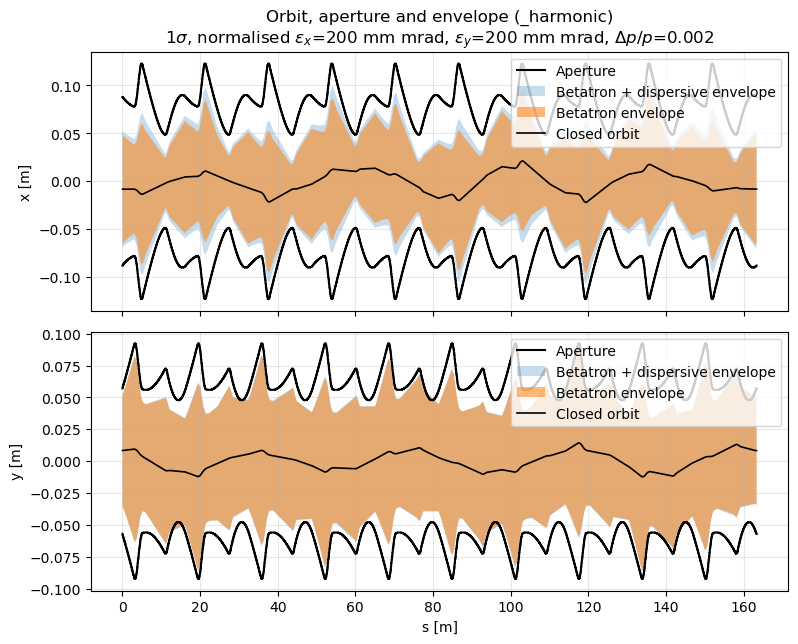

In [26]:
plot_aperture_orbit_envelope_xy(
    twiss_df=twiss_df_harmonic,
    aperture_df=aperture_df,
    beam_state=beam_state,
    emittance_x_mm_mrad=200.0,
    emittance_y_mm_mrad=200.0,
    emittance_is_normalised=True,
    n_sigma=1.0,
    delta_p=0.002,
    label="(_harmonic)",
)

## Loaded-file checks


In [27]:
print("Default loaded files:")
model_default.print_loaded_files()

print("Misaligned loaded files:")
model_misaligned.print_loaded_files()

print("Random-corrector loaded files:")
model_random_correctors.print_loaded_files()


Default loaded files:
../Lattice_Files/00_Simplified_Lattice/ISIS.elements
../Lattice_Files/00_Simplified_Lattice/ISIS.sequence
../Lattice_Files/00_Simplified_Lattice/ISIS.strength
../Lattice_Files/00_Simplified_Lattice/ISIS.aperture
./machine_states/machine_state_default.strength
Misaligned loaded files:
../Lattice_Files/00_Simplified_Lattice/ISIS.elements
../Lattice_Files/00_Simplified_Lattice/ISIS.sequence
../Lattice_Files/00_Simplified_Lattice/ISIS.strength
../Lattice_Files/00_Simplified_Lattice/ISIS.aperture
./machine_states/machine_state_misaligned.strength
../Error_Tables/jan26_survey_corrected_hmatch.tfs
Random-corrector loaded files:
../Lattice_Files/00_Simplified_Lattice/ISIS.elements
../Lattice_Files/00_Simplified_Lattice/ISIS.sequence
../Lattice_Files/00_Simplified_Lattice/ISIS.strength
../Lattice_Files/00_Simplified_Lattice/ISIS.aperture
./machine_states/machine_state_ops_correctors.strength
../Error_Tables/jan26_survey_corrected_hmatch.tfs


## Foundation assertions: loaded files

These checks lock down the file-loading contract used by the model layer.


In [28]:
from pathlib import Path


def loaded_file_names(model):
    return [Path(path).name for path in model.loaded_files]


base_loaded_names = [
    "ISIS.elements",
    "ISIS.sequence",
    "ISIS.strength",
    "ISIS.aperture",
]

expected_default_loaded = base_loaded_names + [Path(state_file_default).name]
expected_misaligned_loaded = (
    base_loaded_names
    + [Path(state_file_misaligned).name, Path(ERROR_TABLE_PATH).name]
)
expected_random_corrector_loaded = (
    base_loaded_names
    + [Path(state_file_random_correctors).name, Path(ERROR_TABLE_PATH).name]
)

assert loaded_file_names(model_default) == expected_default_loaded
assert loaded_file_names(model_misaligned) == expected_misaligned_loaded
assert loaded_file_names(model_random_correctors) == expected_random_corrector_loaded

for model in [model_default, model_misaligned, model_random_correctors]:
    names = loaded_file_names(model)
    assert "ISIS.elements" in names
    assert "ISIS.sequence" in names
    assert "ISIS.strength" in names
    assert "2023.strength" not in names
    assert "ISIS.injected_beam" not in names

assert Path(state_file_default).name in loaded_file_names(model_default)
assert Path(state_file_misaligned).name in loaded_file_names(model_misaligned)
assert Path(state_file_random_correctors).name in loaded_file_names(model_random_correctors)

print("Default loaded file order:", loaded_file_names(model_default))


Default loaded file order: ['ISIS.elements', 'ISIS.sequence', 'ISIS.strength', 'ISIS.aperture', 'machine_state_default.strength']


## Foundation assertions: TWISS outputs

These checks keep the baseline optics tables suitable for the next GUI layer.


In [29]:
required_twiss_columns = {"s", "betx", "bety", "x", "y"}


def assert_twiss_foundation(label, twiss_df, summary_df):
    assert not twiss_df.empty, f"{label} TWISS table is empty"
    assert not summary_df.empty, f"{label} summary table is empty"

    missing_columns = required_twiss_columns.difference(twiss_df.columns)
    assert not missing_columns, f"{label} missing TWISS columns: {sorted(missing_columns)}"

    q1 = float(summary_df["q1"].iloc[0])
    q2 = float(summary_df["q2"].iloc[0])
    assert np.isfinite(q1), f"{label} q1 is not finite"
    assert np.isfinite(q2), f"{label} q2 is not finite"

    final_s = float(twiss_df["s"].max())
    assert 150.0 < final_s < 170.0, f"{label} final s is not ISIS RCS-like: {final_s}"

    if "length" in summary_df.columns:
        circumference = float(summary_df["length"].iloc[0])
        assert 150.0 < circumference < 170.0
        assert abs(circumference - final_s) < 1.0e-6


for label, twiss_df, summary_df in [
    ("default", twiss_df_default, summary_df_default),
    ("misaligned", twiss_df_misaligned, summary_df_misaligned),
    ("ops_correctors", twiss_df_random_correctors, summary_df_random_correctors),
    ("tune_low", twiss_df_tune_low, summary_df_tune_low),
    ("tune_high", twiss_df_tune_high, summary_df_tune_high),
    ("madx_match", twiss_df_madx_match, summary_df_madx_match),
    ("madx_match_file", twiss_df_madx_match_file, summary_df_madx_match_file),
    ("harmonic", twiss_df_harmonic, summary_df_harmonic),
]:
    assert_twiss_foundation(label, twiss_df, summary_df)

print("TWISS foundation assertions passed")


TWISS foundation assertions passed


## Foundation assertions: error-table persistence

These checks ensure applied alignment errors change the orbit and survive subsequent TWISS calls.


In [30]:
def max_orbit_delta(df_a, df_b):
    assert len(df_a) == len(df_b), "TWISS tables must have matching rows for orbit comparison"
    dx = np.max(np.abs(df_a["x"].to_numpy() - df_b["x"].to_numpy()))
    dy = np.max(np.abs(df_a["y"].to_numpy() - df_b["y"].to_numpy()))
    return max(float(dx), float(dy))


misaligned_orbit_delta = max_orbit_delta(twiss_df_misaligned, twiss_df_default)
assert misaligned_orbit_delta > 1.0e-8, "Error table did not change the closed orbit"
assert model_misaligned.metadata["errors_applied"] is True
assert model_misaligned.metadata["error_table_path"] == ERROR_TABLE_PATH

twiss_df_misaligned_rerun = model_misaligned.run_twiss()
summary_df_misaligned = model_misaligned.get_summary_df()
rerun_orbit_delta = max_orbit_delta(twiss_df_misaligned_rerun, twiss_df_default)
assert rerun_orbit_delta > 1.0e-8, "run_twiss erased the applied errors"
assert model_misaligned.metadata["errors_applied"] is True
assert model_misaligned.metadata["error_table_path"] == ERROR_TABLE_PATH

print("Error-table orbit delta:", misaligned_orbit_delta)
print("Error-table orbit delta after rerun:", rerun_orbit_delta)


Error-table orbit delta: 0.021853543970120848
Error-table orbit delta after rerun: 0.021853543970120848


## Foundation assertions: direct MachineState application

Applying a `MachineState` object directly should agree with applying the generated machine-state file.


In [31]:
import tempfile

direct_state_output_dir = tempfile.mkdtemp(prefix="madx_direct_machine_state_")
model_direct_state = MadxModel(
    lattice_folder=LATTICE_FOLDER,
    sequence_name=SEQUENCE_NAME,
    aperture_file=APERTURE_FILE,
    output_dir=direct_state_output_dir,
)
model_direct_state.load_lattice(use_sequence=False)
model_direct_state.apply_machine_state(machine_state_default)
model_direct_state.use_sequence()
twiss_df_direct_state = model_direct_state.run_twiss()
summary_df_direct_state = model_direct_state.get_summary_df()

for tune_column in ["q1", "q2", "dq1", "dq2"]:
    direct_value = float(summary_df_direct_state[tune_column].iloc[0])
    file_value = float(summary_df_default[tune_column].iloc[0])
    assert abs(direct_value - file_value) < 1.0e-9, tune_column

for twiss_column in ["s", "betx", "bety", "x", "y"]:
    direct_values = twiss_df_direct_state[twiss_column].to_numpy()
    file_values = twiss_df_default[twiss_column].to_numpy()
    assert len(direct_values) == len(file_values)
    assert np.max(np.abs(direct_values - file_values)) < 1.0e-9, twiss_column

assert model_direct_state.metadata["machine_state_applied"] is True
assert model_direct_state.metadata["machine_state_cycle_time_ms"] == machine_state_default.cycle_time_ms

print("Direct MachineState application matches generated machine-state file")


Direct MachineState application matches generated machine-state file


## Foundation assertions: missing-file failures

These negative checks make missing input files fail clearly.


In [32]:
def assert_raises(expected_exception, action, message):
    try:
        action()
    except expected_exception as exc:
        print("Caught expected error:", exc)
    else:
        raise AssertionError(message)


def quit_model(model):
    if model.madx is not None:
        try:
            model.madx.quit()
        except Exception:
            pass


with tempfile.TemporaryDirectory(prefix="madx_missing_lattice_") as tmpdir:
    missing_lattice_model = MadxModel(
        lattice_folder=LATTICE_FOLDER,
        sequence_name=SEQUENCE_NAME,
        elements_file="missing.elements",
        output_dir=tmpdir,
    )
    assert_raises(
        FileNotFoundError,
        missing_lattice_model.load_lattice,
        "Expected FileNotFoundError for missing lattice file",
    )
    quit_model(missing_lattice_model)

with tempfile.TemporaryDirectory(prefix="madx_missing_state_") as tmpdir:
    missing_state_model = MadxModel(
        lattice_folder=LATTICE_FOLDER,
        sequence_name=SEQUENCE_NAME,
        machine_state_file="./machine_states/not_a_machine_state.strength",
        aperture_file=APERTURE_FILE,
        output_dir=tmpdir,
    )
    assert_raises(
        FileNotFoundError,
        missing_state_model.load_lattice,
        "Expected FileNotFoundError for missing machine-state file",
    )
    quit_model(missing_state_model)

with tempfile.TemporaryDirectory(prefix="madx_missing_error_table_") as tmpdir:
    missing_error_model = MadxModel(
        lattice_folder=LATTICE_FOLDER,
        sequence_name=SEQUENCE_NAME,
        machine_state_file=state_file_default,
        aperture_file=APERTURE_FILE,
        output_dir=tmpdir,
    )
    missing_error_model.load_lattice(use_sequence=True)
    assert_raises(
        FileNotFoundError,
        lambda: missing_error_model.apply_error_table("../Error_Tables/not_an_error_table.tfs"),
        "Expected FileNotFoundError for missing error table",
    )
    quit_model(missing_error_model)

print("Missing-file failure assertions passed")


Caught expected error: Missing elements file: ../Lattice_Files/00_Simplified_Lattice/missing.elements
Caught expected error: Missing machine-state file: ./machine_states/not_a_machine_state.strength
Caught expected error: Missing MAD-X error table: ../Error_Tables/not_an_error_table.tfs
Missing-file failure assertions passed
